# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Achmad Miftachul Tama
- Email: miftachultama22@gmail.com
- Id Dicoding:temzone

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import os
import pickle
import joblib
import shap


from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, f1_score, make_scorer


ModuleNotFoundError: No module named 'imblearn'

### Menyiapkan data yang akan diguankan

In [ ]:
df = pd.read_csv('dataset/employee_data.csv');

In [ ]:
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding

In [ ]:
print("Shape:", df.shape)

Shape: (1470, 35)


In [ ]:
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  J

In [ ]:
print("\nMissing Values:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])


Missing Values:
Attrition    412
dtype: int64


In [ ]:
# Duplicate check
print("\nDuplikat:", df.duplicated().sum())


Duplikat: 0


In [ ]:
print("\nAttrition Rate:")
print(df['Attrition'].value_counts(normalize=True).round(4)*100)


Attrition Rate:
Attrition
0.0    83.08
1.0    16.92
Name: proportion, dtype: float64


In [ ]:
# Statistik deskriptif
print("\nDescribe:")
print(df.describe())


Describe:
        EmployeeId          Age    Attrition    DailyRate  DistanceFromHome  \
count  1470.000000  1470.000000  1058.000000  1470.000000       1470.000000   
mean    735.500000    36.923810     0.169187   802.485714          9.192517   
std     424.496761     9.135373     0.375094   403.509100          8.106864   
min       1.000000    18.000000     0.000000   102.000000          1.000000   
25%     368.250000    30.000000     0.000000   465.000000          2.000000   
50%     735.500000    36.000000     0.000000   802.000000          7.000000   
75%    1102.750000    43.000000     0.000000  1157.000000         14.000000   
max    1470.000000    60.000000     1.000000  1499.000000         29.000000   

         Education  EmployeeCount  EnvironmentSatisfaction   HourlyRate  \
count  1470.000000         1470.0              1470.000000  1470.000000   
mean      2.912925            1.0                 2.721769    65.891156   
std       1.024165            0.0                 1.

In [ ]:
# Visualisasi target

# Menampilkan jumlah tiap nilai di kolom Attrition
print("Jumlah Attrition:")
print(df['Attrition'].value_counts(dropna=False))

fig = px.pie(df, names='Attrition', title='Proporsi Attrition (0 = Stay, 1 = Resign)')
fig.show()

Jumlah Attrition:
Attrition
0.0    879
NaN    412
1.0    179
Name: count, dtype: int64


Berdasarkan Informasi yang diberkan bahwa attrition rate lebih dari 10%,

disini kita bisa lihat lebih detil bahwa ada 12.2% karyawan yang melakukan resign, serta terdapat null value >25% yang mungkin bisa saja itu merupakan data karyawan yang resign.

In [ ]:
# Univariate plots untuk faktor kunci

cat_cols = ['OverTime', 'JobSatisfaction','EnvironmentSatisfaction']



for col in cat_cols:

    fig = px.histogram(df, x=col, color='Attrition', barmode='group',

    title=f'Distribusi {col} vs Attrition')

    fig.show()

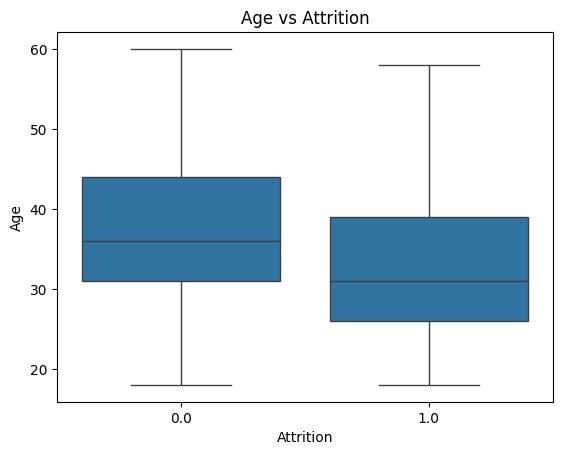

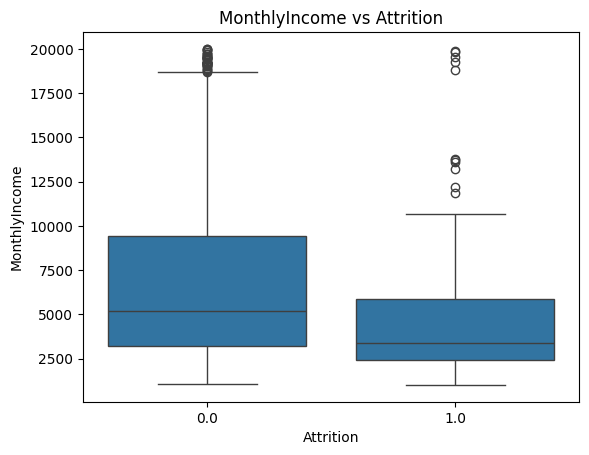

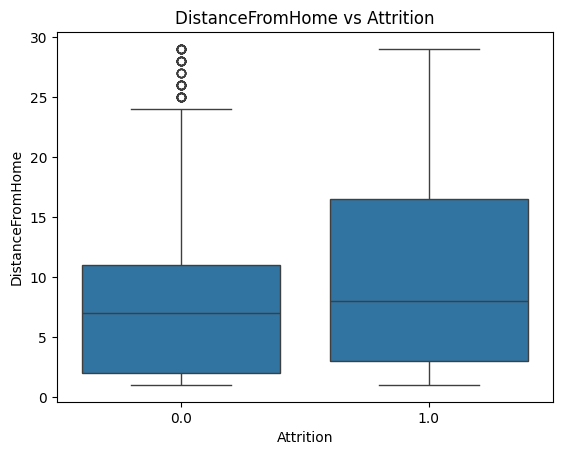

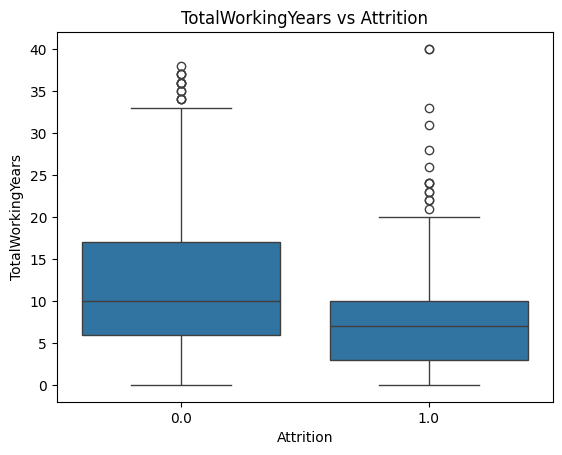

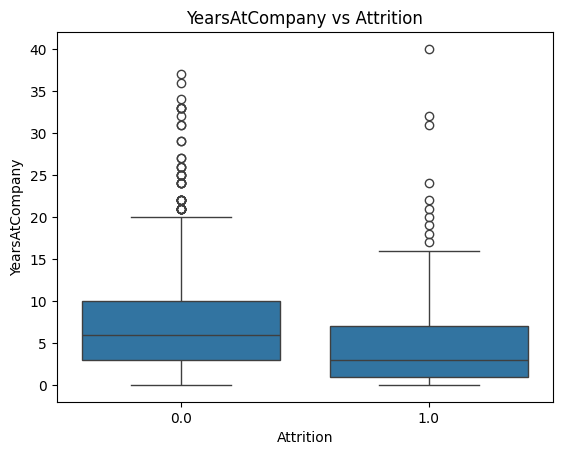

In [ ]:
num_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'TotalWorkingYears', 'YearsAtCompany']

for col in num_cols:
    sns.boxplot(x='Attrition', y=col, data=df)
    plt.title(f'{col} vs Attrition')
    plt.show()

**OverTime** = Karyawan yang melakukan resign merasakan overtime, walau perbedaan tidak terlalu signifikan.

namun untuk karyawan yang stay mayoritas tidak merasakan overtime, terlihat jauh sekali perbedaannya.

**MonthlyIncome rendah + DistanceFromHome tinggi** = resign lebih banyak


## Data Preparation / Preprocessing

In [ ]:
print(df['Over18'].nunique())
print(df['StandardHours'].nunique())
print(df['EmployeeCount'].nunique())

1
1
1


In [ ]:
# Menghitung jumlah spesifik nilai 1 (Resign)
total_attrition_1 = df[df['Attrition'] == 1].shape[0]

print(f"Total karyawan yang resign (Attrition = 1): {total_attrition_1}")

# Atau jika ingin melihat sebarannya
print(df['Attrition'].value_counts())

Total karyawan yang resign (Attrition = 1): 179
Attrition
0.0    879
1.0    179
Name: count, dtype: int64


In [ ]:
# Drop null value
df_clean = df.dropna(subset=['Attrition']).copy()

In [ ]:
# Drop kolom useless / constant
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours']
df_clean = df_clean.drop(columns=drop_cols, errors='ignore')

In [ ]:
# Feature Engineering sederhana
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=[18,25,35,45,60], labels=['Young','Mid','Senior','Old'], include_lowest=True)

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 1 to 1469
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   EmployeeId                1058 non-null   int64   
 1   Age                       1058 non-null   int64   
 2   Attrition                 1058 non-null   float64 
 3   BusinessTravel            1058 non-null   object  
 4   DailyRate                 1058 non-null   int64   
 5   Department                1058 non-null   object  
 6   DistanceFromHome          1058 non-null   int64   
 7   Education                 1058 non-null   int64   
 8   EducationField            1058 non-null   object  
 9   EnvironmentSatisfaction   1058 non-null   int64   
 10  Gender                    1058 non-null   object  
 11  HourlyRate                1058 non-null   int64   
 12  JobInvolvement            1058 non-null   int64   
 13  JobLevel                  1058 non-null   int64   
 1

In [ ]:
# Simpan Dataset
df_clean.to_csv('attrition_clean.csv', index=False)
df_clean.to_excel('attrition_clean.xlsx', index=False)
df.to_excel('attrition_data.xlsx', index=False)

In [ ]:
df_clean = df_clean.drop(columns='EmployeeId', errors='ignore')

## Modeling

In [ ]:
# Encoding categorical
cat_cols = df_clean.select_dtypes(include=['object','category']).columns
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    le_dict[col] = le
    print(f"✓ {col} telah di-encode")

✓ BusinessTravel telah di-encode
✓ Department telah di-encode
✓ EducationField telah di-encode
✓ Gender telah di-encode
✓ JobRole telah di-encode
✓ MaritalStatus telah di-encode
✓ OverTime telah di-encode
✓ AgeGroup telah di-encode


In [ ]:
# Hapus Target Pada Data Train

X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

In [ ]:
# Split Data 80:20

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train attrition rate: {y_train.mean():.1%}")
print(f"Test attrition rate: {y_test.mean():.1%}")

Train: (846, 31), Test: (212, 31)
Train attrition rate: 16.9%
Test attrition rate: 17.0%


In [ ]:
# Ambil nama kolom dari data X (sebelum SMOTE/Resampling)
feature_columns = X_train.columns.tolist()

# Cek isinya
print(f"Jumlah fitur: {len(feature_columns)}")
print("List Fitur:", feature_columns)

Jumlah fitur: 31
List Fitur: ['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'AgeGroup']


In [ ]:
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print('Sebelum SMOTETomek:')
print(f'  Class 0: {(y_train==0).sum()}')
print(f'  Class 1: {(y_train==1).sum()}')
print('\nSetelah SMOTETomek:')
print(f'  Class 0: {(y_train_res==0).sum()}')
print(f'  Class 1: {(y_train_res==1).sum()}')

Sebelum SMOTETomek:
  Class 0: 703
  Class 1: 143

Setelah SMOTETomek:
  Class 0: 663
  Class 1: 663


**SMOTETomek** diterapkan untuk menangani imbalanced data. Teknik ini menggabungkan SMOTE untuk menambah sampel kelas minoritas dan Tomek Links untuk menghapus data yang ambigu, sehingga batas keputusan model (decision boundary) menjadi lebih jelas

In [ ]:
# Train 3 model dan pilih yang terbaik diantara 3

models = {
    'Gradient Boost Tree': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    results[name] = y_pred


## Evaluation

In [ ]:
print("=" * 65)
# Loop langsung ke semua model yang ada di dictionary
for name, model in models.items():

    # 1. Ambil Probabilitas (Class 1 / Resign)
    # Kita pakai X_test langsung karena semua model sisa adalah Tree-based
    y_proba = model.predict_proba(X_test)[:, 1]

    # 2. Cari Threshold Optimal (Titik keseimbangan Precision & Recall)
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    # Tambah 1e-8 biar nggak error division by zero kalau ada yang 0
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    # 3. Prediksi ulang pakai Threshold Optimal hasil itungan di atas
    y_pred_tuned = (y_proba >= best_threshold).astype(int)

    # 4. Hitung Report Lengkap
    report = classification_report(y_test, y_pred_tuned, output_dict=True)

    # Handle key class 1 (antisipasi kalau output dict-nya beda tipe data)
    class1_key = None
    for k in [1, '1', 1.0, '1.0']:
        if k in report:
            class1_key = k
            break

    prec1   = report[class1_key]['precision']
    rec1    = report[class1_key]['recall']
    f1_1    = report[class1_key]['f1-score']
    roc_auc = roc_auc_score(y_test, y_proba)

    # 5. Tampilkan Hasil Perbandingan
    print(f"Model : {name}")
    print(f"  Best Threshold      : {best_threshold:.3f}")
    print(f"  Precision (resign)  : {prec1:.3f}")
    print(f"  Recall    (resign)  : {rec1:.3f}")
    print(f"  F1 Score  (resign)  : {f1_1:.3f}")
    print(f"  ROC-AUC             : {roc_auc:.3f}")
    print("-" * 65)

Model : Gradient Boost Tree
  Best Threshold      : 0.506
  Precision (resign)  : 0.475
  Recall    (resign)  : 0.528
  F1 Score  (resign)  : 0.500
  ROC-AUC             : 0.758
-----------------------------------------------------------------
Model : Random Forest
  Best Threshold      : 0.390
  Precision (resign)  : 0.440
  Recall    (resign)  : 0.611
  F1 Score  (resign)  : 0.512
  ROC-AUC             : 0.771
-----------------------------------------------------------------
Model : XGBoost
  Best Threshold      : 0.339
  Precision (resign)  : 0.457
  Recall    (resign)  : 0.583
  F1 Score  (resign)  : 0.512
  ROC-AUC             : 0.742
-----------------------------------------------------------------


**Model Training & Optimization**

Tiga model berbasis Ensemble Tree (Random Forest, Gradient Boosting, dan XGBoost) dilatih pada data yang telah diseimbangkan. Evaluasi tidak hanya menggunakan default threshold (0.5), melainkan mencari Optimal Threshold melalui kurva Precision-Recall untuk mendapatkan keseimbangan terbaik antara akurasi prediksi dan sensitivitas terhadap karyawan yang berisiko resign.

In [ ]:
model_final = models["Random Forest"]

In [ ]:
feat_imp = pd.DataFrame({
    'Feature'   : feature_columns,
    'Importance': model_final.feature_importances_
}).sort_values('Importance', ascending=False)

print(feat_imp.head(10).to_string(index=False))

                Feature  Importance
       StockOptionLevel    0.166554
            MonthlyRate    0.066951
        JobSatisfaction    0.060002
         JobInvolvement    0.059477
      TotalWorkingYears    0.055280
EnvironmentSatisfaction    0.053755
          MonthlyIncome    0.050526
        WorkLifeBalance    0.044778
  TrainingTimesLastYear    0.035314
         BusinessTravel    0.034899


**Feature Importance & Model Export**

Setelah mendapatkan model terbaik, dilakukan analisis fitur yang paling berpengaruh terhadap keputusan karyawan untuk keluar. Terakhir, seluruh komponen model—termasuk scaler (jika ada), encoder, daftar fitur, dan optimal threshold—disimpan ke dalam format pickle untuk kebutuhan deployment sistem prediksi.

In [ ]:
# Simpan model

os.makedirs('model', exist_ok=True)

model_final = models['Random Forest']

with open('model/attrition_model.pkl', 'wb') as f:
    pickle.dump(model_final, f)

with open('model/label_encoders.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('model/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns  , f)

with open('model/threshold.pkl', 'wb') as f:
    pickle.dump(best_threshold, f)

print("✓ Semua file tersimpan di folder 'model':")
for f in os.listdir('model'):
    size = os.path.getsize(f'model/{f}')
    print(f"  model/{f}  ({size/1024:.1f} KB)")

✓ Semua file tersimpan di folder 'model':
  model/threshold.pkl  (0.1 KB)
  model/feature_columns.pkl  (0.5 KB)
  model/sample_data  (4.0 KB)
  model/attrition_model.pkl  (4787.2 KB)
  model/label_encoders.pkl  (0.3 KB)
